In [23]:
import pandas as pd
import matplotlib.pyplot as plt


In [14]:
df_finance_raw = pd.read_csv("rekstur_data.csv")

In [27]:
metric_map = {
    "1. Tekjur alls": "Operating Revenue",
    "2  Gjöld alls": "Operating Expenses",
    "Hreinn hagnaður (EBT)": "Net Profit",
    "Verg hlutdeild fjármagns (EBITDA)": "EBITDA",
}

# Filter to selected metrics and "Samtals" (total across all ship types)
df_finance = df_finance_raw[
    (df_finance_raw["Tekju- og gjaldaliðir"].isin(metric_map.keys()))
    & (df_finance_raw["Tegund skipa"] == "Samtals")
].copy()

# Translate and rename
df_finance["Metric"] = df_finance["Tekju- og gjaldaliðir"].map(metric_map)
df_finance.rename(columns={
    "Ár": "Year",
    "Rekstraryfirlit fiskveiða 1997-2024": "Amount"
}, inplace=True)

# Convert to numeric
df_finance["Amount"] = pd.to_numeric(df_finance["Amount"], errors="coerce")

# Pivot to one row per year
df_finance = (
    df_finance
    .pivot_table(index="Year", columns="Metric", values="Amount", aggfunc="first")
    .reset_index()
)
df_finance.columns.name = None

df_finance.head(50)

,Year,EBITDA,Net Profit,Operating Expenses,Operating Revenue
0,1997,10129,-1041,49574,59703
1,1998,12396,670,50391,62787
2,1999,11893,135,52130,64023
3,2000,12120,-4816,50427,62548
4,2001,18580,-1571,57464,76043
5,2002,19428,13038,63306,82734
6,2003,15037,2470,55455,70492
7,2004,12254,2683,59227,71481
8,2005,14548,8640,60027,74575
9,2006,19785,-10230,61748,81533


In [17]:
df_finance_raw["Tekju- og gjaldaliðir"].unique()


array(['1. Tekjur alls', '1.1  Útflutningstekjur', '1.2  Selt hráefni',
       '1.3  Aðrar tekjur', '2  Gjöld alls', '2.1  Aflahlutir',
       '2.2  Önnur laun', '2.3  Launatengd gjöld', '2.4  Olíur',
       '2.5  Veiðarfæri', '2.6  Viðhald',
       '2.7  Frystikostn. umbúðir og fl.', '2.8  Flutningskostnaður',
       '2.9  Laun v/skrifstofu', '2.10 Skrifst.kostnaður',
       '2.11  Tryggingar', '2.12 Sölukostnaður', '2.13 Löndunarkostnaður',
       '2.14 Kvótaleiga', '2.15 Önnur gjöld',
       'Verg hlutdeild fjármagns (EBITDA)',
       'EBITDA sem hlutfall af tekjum, %', 'Afskriftir',
       'Verðbreytingarfærsla og vextir', 'Hreinn hagnaður (EBT)',
       'Hreinn hagnaður sem hlutfall af tekjum, %', 'Árgreiðsla, 6%',
       'Hreinn hagnaður - árgreiðsla', 'sem hlutfall af tekjum, %'],
      dtype=object)

/var/folders/rs/xp_jvmcs6yxft09g6r_s670m0000gn/T/ipykernel_2392/2446219014.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


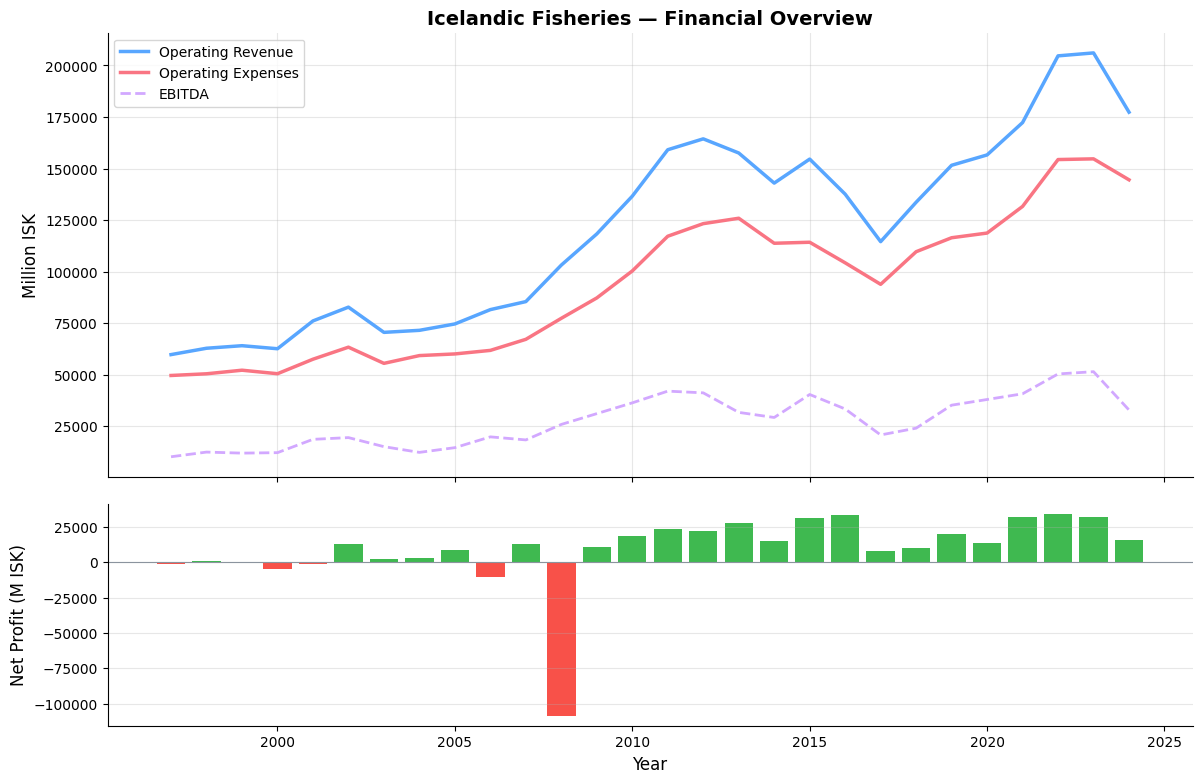

In [26]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), height_ratios=[2, 1],
                                sharex=True, gridspec_kw={"hspace": 0.08})

# ── Top: Revenue, Expenses, EBITDA ──
ax1.plot(df_finance["Year"], df_finance["Operating Revenue"], linewidth=2.5,
         label="Operating Revenue", color="#58a6ff")
ax1.plot(df_finance["Year"], df_finance["Operating Expenses"], linewidth=2.5,
         label="Operating Expenses", color="#f97583")
ax1.plot(df_finance["Year"], df_finance["EBITDA"], linewidth=2,
         label="EBITDA", color="#d2a8ff", linestyle="--")

ax1.set_ylabel("Million ISK", fontsize=12)
ax1.set_title("Icelandic Fisheries — Financial Overview", fontsize=14, fontweight="bold")
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.spines[["top", "right"]].set_visible(False)

# ── Bottom: Net Profit bars (green/red) ──
colors = ["#3fb950" if v >= 0 else "#f85149" for v in df_finance["Net Profit"]]
ax2.bar(df_finance["Year"], df_finance["Net Profit"], color=colors, edgecolor="none", width=0.8)
ax2.axhline(0, color="#8b949e", linewidth=0.8)

ax2.set_xlabel("Year", fontsize=12)
ax2.set_ylabel("Net Profit (M ISK)", fontsize=12)
ax2.grid(True, alpha=0.3, axis="y")
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()